In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
import spacy
import time
import json
sns.set(style="whitegrid")

In [ ]:
file_path = "C:\SQUAD\squad_train-v2.0.json"

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\dkmho\AppData\Local\Temp\ipykernel_13604\2699341873.py:1: SyntaxWarning: invalid escape sequence '\S'
  file_path = "C:\SQUAD\squad_train-v2.0.json"


In [ ]:
def squad_json_to_df(file_path):
    with open(file_path, 'r') as f:
        squad = json.load(f)

    data = []
    for article in squad['data']:
        title = article['title']
        for paragraph in article['paragraphs']:
            context = paragraph['context']
            for qa in paragraph['qas']:
                # Handle SQuAD 2.0 format
                is_impossible = qa.get('is_impossible', False)  # Key addition
                answers = qa.get('answers', [])

                row = {
                    'id': qa['id'],
                    'title': title,
                    'context': context,
                    'question': qa['question'],
                    'is_impossible': is_impossible,
                    'answers': answers
                }
                data.append(row)

    return pd.DataFrame(data)

In [ ]:
squad_df = squad_json_to_df(file_path)
print(squad_df.columns)

Index(['id', 'title', 'context', 'question', 'is_impossible', 'answers'], dtype='object')


In [ ]:
print(squad_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130319 entries, 0 to 130318
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             130319 non-null  object
 1   title          130319 non-null  object
 2   context        130319 non-null  object
 3   question       130319 non-null  object
 4   is_impossible  130319 non-null  bool  
 5   answers        130319 non-null  object
dtypes: bool(1), object(5)
memory usage: 5.1+ MB
None


In [ ]:
output_file = "squad_dataset_final.xlsx"
squad_df.to_excel(output_file, index=False, engine='openpyxl')
print(f"Dataset successfully saved as {output_file}")

Dataset successfully saved as squad_dataset_final.xlsx


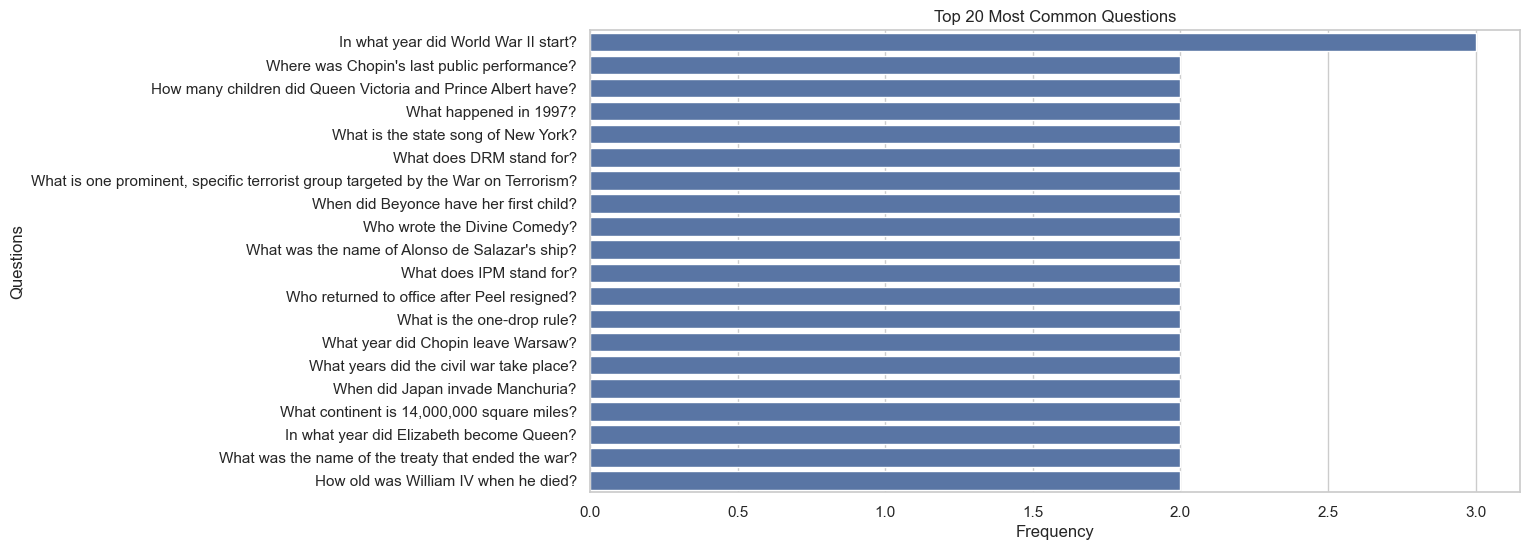

In [ ]:
# Count unique questions and their frequency
question_counts = squad_df['question'].value_counts()

# Plotting question frequency distribution
plt.figure(figsize=(12, 6))
sns.countplot(y='question', data=squad_df, order=question_counts.index[:20])
plt.title('Top 20 Most Common Questions')
plt.xlabel('Frequency')
plt.ylabel('Questions')
plt.show()

Processing answers: 100%|██████████| 130319/130319 [00:09<00:00, 13745.43it/s]


Processed 86821 answerable questions out of 130319 total


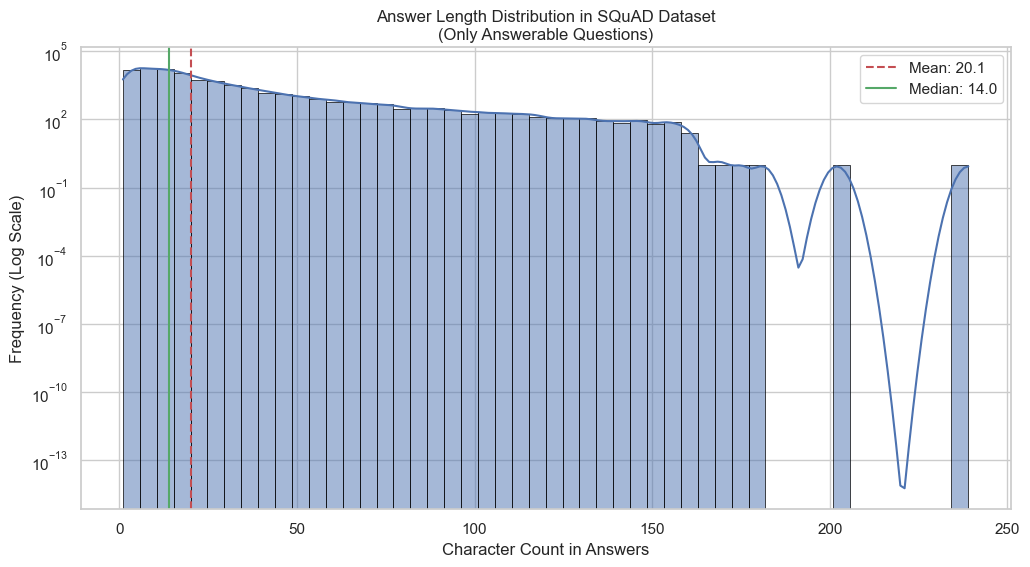

In [ ]:
answer_lengths = []
answerable_count = 0

for index, row in tqdm(squad_df.iterrows(), total=len(squad_df), desc="Processing answers"):
    # Handle SQuAD 2.0's unanswerable questions
    if row['is_impossible']:
        continue

    # Properly access answer text (verify your actual column names)
    if isinstance(row['answers'], list) and len(row['answers']) > 0:
        answer_text = row['answers'][0].get('text', '')  # Use .get() for safety
        answer_lengths.append(len(answer_text))
        answerable_count += 1

print(f"Processed {answerable_count} answerable questions out of {len(squad_df)} total")

# Plotting with enhanced visualization
plt.figure(figsize=(12, 6))
ax = sns.histplot(answer_lengths, bins=50, kde=True,
                 edgecolor='black', linewidth=0.5)

# Add statistical annotations
mean_len = np.mean(answer_lengths)
median_len = np.median(answer_lengths)
plt.axvline(mean_len, color='r', linestyle='--', label=f'Mean: {mean_len:.1f}')
plt.axvline(median_len, color='g', linestyle='-', label=f'Median: {median_len:.1f}')

plt.title('Answer Length Distribution in SQuAD Dataset\n(Only Answerable Questions)')
plt.xlabel('Character Count in Answers')
plt.ylabel('Frequency (Log Scale)')
plt.yscale('log')  # Better for long-tailed distributions
plt.legend()
plt.show()

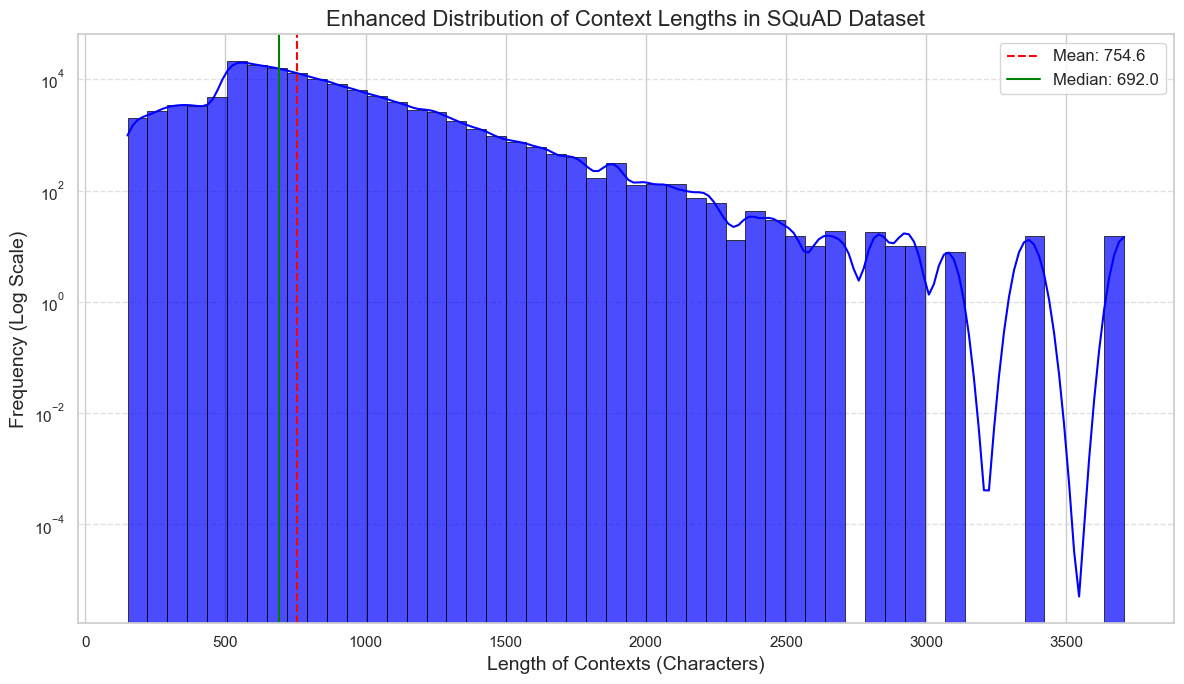

In [ ]:
# Enhanced Context Length Distribution Visualization
plt.figure(figsize=(12, 7))

# Calculate context lengths and store in 'context_lengths'
context_lengths = squad_df['context'].str.len()

# Create histogram with additional aesthetics
sns.histplot(context_lengths, bins=50, kde=True, color='blue', alpha=0.7, edgecolor='black', linewidth=0.5)

# Add statistical annotations
mean_length = context_lengths.mean()
median_length = context_lengths.median()
plt.axvline(mean_length, color='red', linestyle='--', label=f'Mean: {mean_length:.1f}')
plt.axvline(median_length, color='green', linestyle='-', label=f'Median: {median_length:.1f}')

# Improve plot appearance
plt.title('Enhanced Distribution of Context Lengths in SQuAD Dataset', fontsize=16)
plt.xlabel('Length of Contexts (Characters)', fontsize=14)
plt.ylabel('Frequency (Log Scale)', fontsize=14)
plt.yscale('log')  # Log scale for better visualization of long-tailed distributions
plt.grid(axis='y', linestyle='--', alpha=0.6)  # Add grid lines for clarity
plt.legend(fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

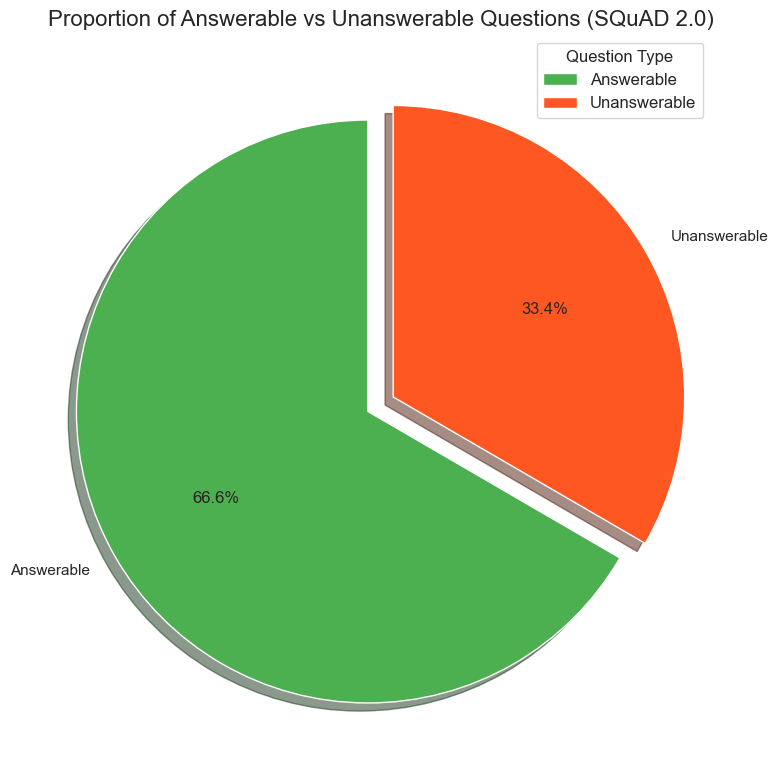

In [ ]:
# Count answerable and unanswerable questions
answerable_counts = squad_df['is_impossible'].value_counts()

# Create a pie chart with enhancements
plt.figure(figsize=(8, 8))

# Define colors for better visual distinction
colors = ['#4CAF50', '#FF5722']  # Green for answerable, Red for unanswerable

# Create pie chart
plt.pie(answerable_counts,
        labels=['Answerable', 'Unanswerable'],
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        explode=(0.1, 0),  # Slightly explode the first slice for emphasis
        shadow=True)  # Add shadow for a 3D effect

# Title and equal aspect ratio
plt.title('Proportion of Answerable vs Unanswerable Questions (SQuAD 2.0)', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular.

# Add a legend
plt.legend(title='Question Type', loc='upper right', fontsize=12)

# Display the enhanced pie chart
plt.tight_layout()
plt.show()

Categorizing Answers 🚀:   0%|          | 0/130319 [00:00<?, ?it/s]C:\Users\dkmho\AppData\Roaming\Python\Python312\site-packages\spacy\pipeline\lemmatizer.py:211: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)
Categorizing Answers 🚀: 100%|██████████| 130319/130319 [01:40<00:00, 1291.96it/s]
C:\Users\dkmho\AppData\Local\Temp\ipykernel_13604\4222653691.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


Execution Time: 100.94 seconds 🚀


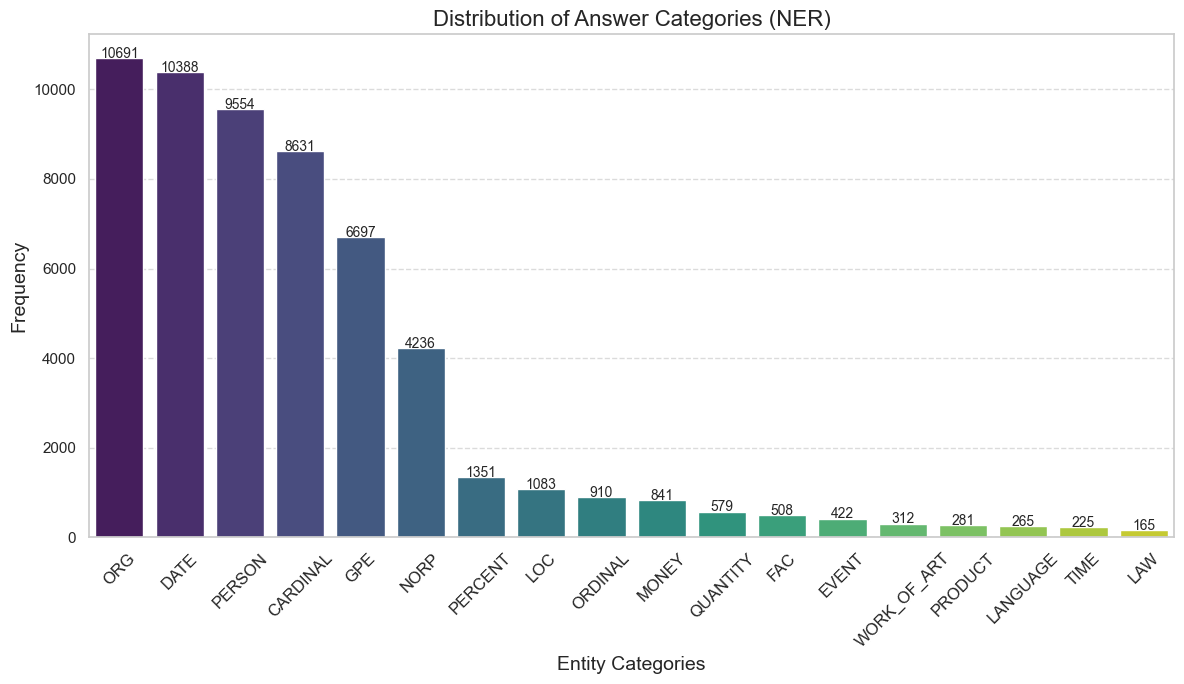

In [ ]:
# Load a pre-trained NER model
nlp = spacy.load("en_core_web_sm", disable=["parser", "tagger"])  # Only use NER for efficiency

# Function to batch-process answers and extract categories efficiently
def categorize_answers_batch(answers_list):
    categories_list = []
    texts = [answers[0]['text'] if answers else "" for answers in answers_list]  # Extract text from first answer

    # Process all answers in batch using `nlp.pipe()`
    for doc in tqdm(nlp.pipe(texts, batch_size=64), total=len(texts), desc="Categorizing Answers 🚀"):
        categories = {ent.label_ for ent in doc.ents}  # Use set for unique categories
        categories_list.append(list(categories))

    return categories_list

# Start timing
start_time = time.time()

# Efficiently categorize answers
squad_df['answer_categories'] = categorize_answers_batch(squad_df['answers'])

# End timing
end_time = time.time()
print(f"Execution Time: {end_time - start_time:.2f} seconds 🚀")

# Flatten the list of categories
all_categories = [cat for sublist in squad_df['answer_categories'] for cat in sublist]

# Count occurrences of each category
category_counts = pd.Series(all_categories).value_counts()

# Enhanced Visualization of Answer Categories
plt.figure(figsize=(12, 7))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")

# Add annotations to the bars
for i, v in enumerate(category_counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontsize=10)

# Add titles and labels
plt.title('Distribution of Answer Categories (NER)', fontsize=16)
plt.xlabel('Entity Categories', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

Analyzing Difficulty: 100%|██████████| 130319/130319 [00:00<00:00, 195081.92it/s]


Execution Time: 0.69 seconds


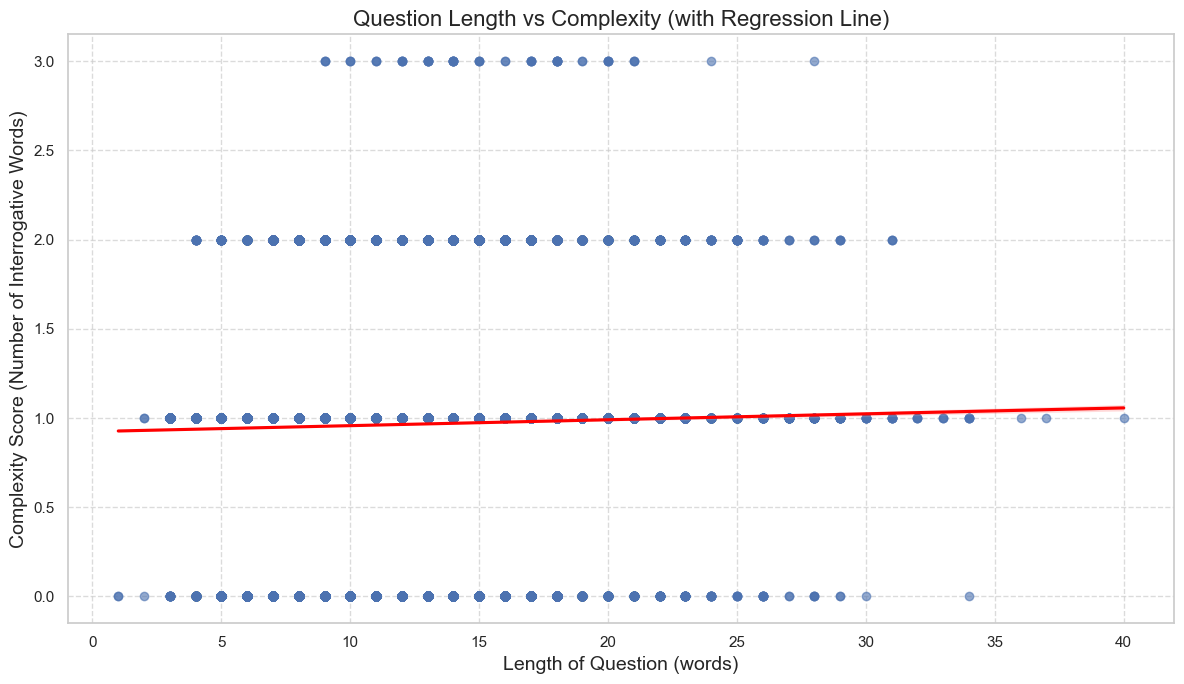

In [ ]:
# List of interrogative words
INTERROGATIVE_WORDS = {'who', 'what', 'where', 'when', 'why', 'how'}

# Function to analyze question difficulty efficiently
def analyze_question_difficulty(questions):
    difficulties = [
        (len(q.split()), sum(word in q.lower() for word in INTERROGATIVE_WORDS))
        for q in tqdm(questions, desc="Analyzing Difficulty")
    ]
    return difficulties

# Apply difficulty analysis with timing
start_time = time.time()
squad_df['difficulty'] = analyze_question_difficulty(squad_df['question'])
end_time = time.time()

print(f"Execution Time: {end_time - start_time:.2f} seconds")

# Convert to DataFrame for easier visualization
difficulty_df = pd.DataFrame(squad_df['difficulty'].tolist(), columns=['length', 'complexity'])

# Enhanced Visualization of Question Length vs Complexity
plt.figure(figsize=(12, 7))

# Create scatter plot with a regression line
sns.regplot(x='length', y='complexity', data=difficulty_df, scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})

# Add titles and labels
plt.title('Question Length vs Complexity (with Regression Line)', fontsize=16)
plt.xlabel('Length of Question (words)', fontsize=14)
plt.ylabel('Complexity Score (Number of Interrogative Words)', fontsize=14)

# Add grid lines for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Vectorizing the questions using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(squad_df['question'])

# Applying K-Means clustering
n_clusters = 5  # You can adjust this number
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(X)

# Adding cluster labels to the DataFrame
squad_df['cluster'] = kmeans.labels_

In [ ]:
# Sample 10,000 questions for faster processing
squad_sample = squad_df.sample(10000, random_state=42)
X_sample = vectorizer.fit_transform(squad_sample['question'])

In [ ]:
import logging
from sklearn.decomposition import TruncatedSVD
from umap import UMAP  # Correct import statement for UMAP
from tqdm import tqdm

# Set up logging
logging.basicConfig(format="%(asctime)s - %(message)s", level=logging.INFO)

try:
    # Sample 10,000 questions from the DataFrame
    squad_sample = squad_df.sample(10000, random_state=42)

    logging.info("Starting dimensionality reduction with TruncatedSVD...")

    # Reduce dimensions with TruncatedSVD (faster than PCA for sparse data)
    svd = TruncatedSVD(n_components=10, random_state=42)  # Reduced to 10 components for faster processing
    X_svd = svd.fit_transform(X_sample)  # Assuming X_sample is defined as TF-IDF vectors of squad_sample['question']

    logging.info(f"TruncatedSVD completed. Reduced shape: {X_svd.shape}")

    logging.info("Running UMAP for dimensionality reduction...")

    # Initialize progress bar based on UMAP fitting process
    pbar = tqdm(total=1, desc="UMAP Progress", position=0, leave=True)

    # Optimized UMAP configuration
    umap = UMAP(
        n_components=2,
        n_neighbors=15,  # Adjusted for better local structure representation
        min_dist=0.1,  # Controls how tightly points are packed together
        metric='euclidean',
        random_state=42,
        verbose=True,
        n_jobs=-1  # Use all available cores for parallel processing
    )

    # Fit UMAP and update progress bar (UMAP does not have a callback like t-SNE)
    X_umap = umap.fit_transform(X_svd)

except Exception as e:
    logging.error(f"An error occurred: {e}")
    X_umap = None  # Set X_umap to None in case of an error

finally:
    pbar.close()
    if X_umap is not None:
        logging.info("UMAP completed! 🚀")
        # Add results to DataFrame only if X_umap was successfully created
        squad_sample['x'] = X_umap[:, 0]
        squad_sample['y'] = X_umap[:, 1]

        # Optionally: Save results or visualize them
        print(squad_sample[['question', 'x', 'y']].head())
    else:
        logging.error("UMAP fitting failed; no results to add to DataFrame.")

C:\Users\dkmho\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-03-19 14:55:18,396 - Starting dimensionality reduction with TruncatedSVD...
2025-03-19 14:55:18,549 - TruncatedSVD completed. Reduced shape: (10000, 10)
2025-03-19 14:55:18,550 - Running UMAP for dimensionality reduction...
UMAP Progress:   0%|          | 0/1 [00:00<?, ?it/s]C:\Users\dkmho\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\dkmho\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, random_state=42, verbose=True)
Wed Mar 19 14:55:19 2025 Construct fuzzy simplicial set
Wed Mar 19 14:55:19 2025 Finding Nearest Neighbors
Wed Mar 19 14:55:19 2025 Building RP forest with 10 trees
Wed Mar 19 14:55:29 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Wed Mar 19 14:55:47 2025 Finished Nearest Neighbor Search
Wed Mar 19 14:55:51 2025 Construct embedding


	completed  0  /  500 epochs


	completed  50  /  500 epochs


	completed  100  /  500 epochs


...

	completed  350  /  500 epochs


	completed  400  /  500 epochs


	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:35]
UMAP Progress:   0%|          | 0/1 [01:09<?, ?it/s]
2025-03-19 14:56:28,097 - UMAP completed! 🚀


Wed Mar 19 14:56:28 2025 Finished embedding
                                                 question          x  \
125137  What year did the global recession that follow...   0.003797   
30275   what was a popular club in ibiza that started ...  10.455573   
39176   In what century did Martin Luther honor Mary a...  -2.612701   
32129                           What is the climate like?   9.888378   
44136         How many times has the Queen toured Canada?  11.504090   

                y  
125137  14.148147  
30275   -0.997961  
39176    5.621826  
32129   -4.323377  
44136   -3.701424  


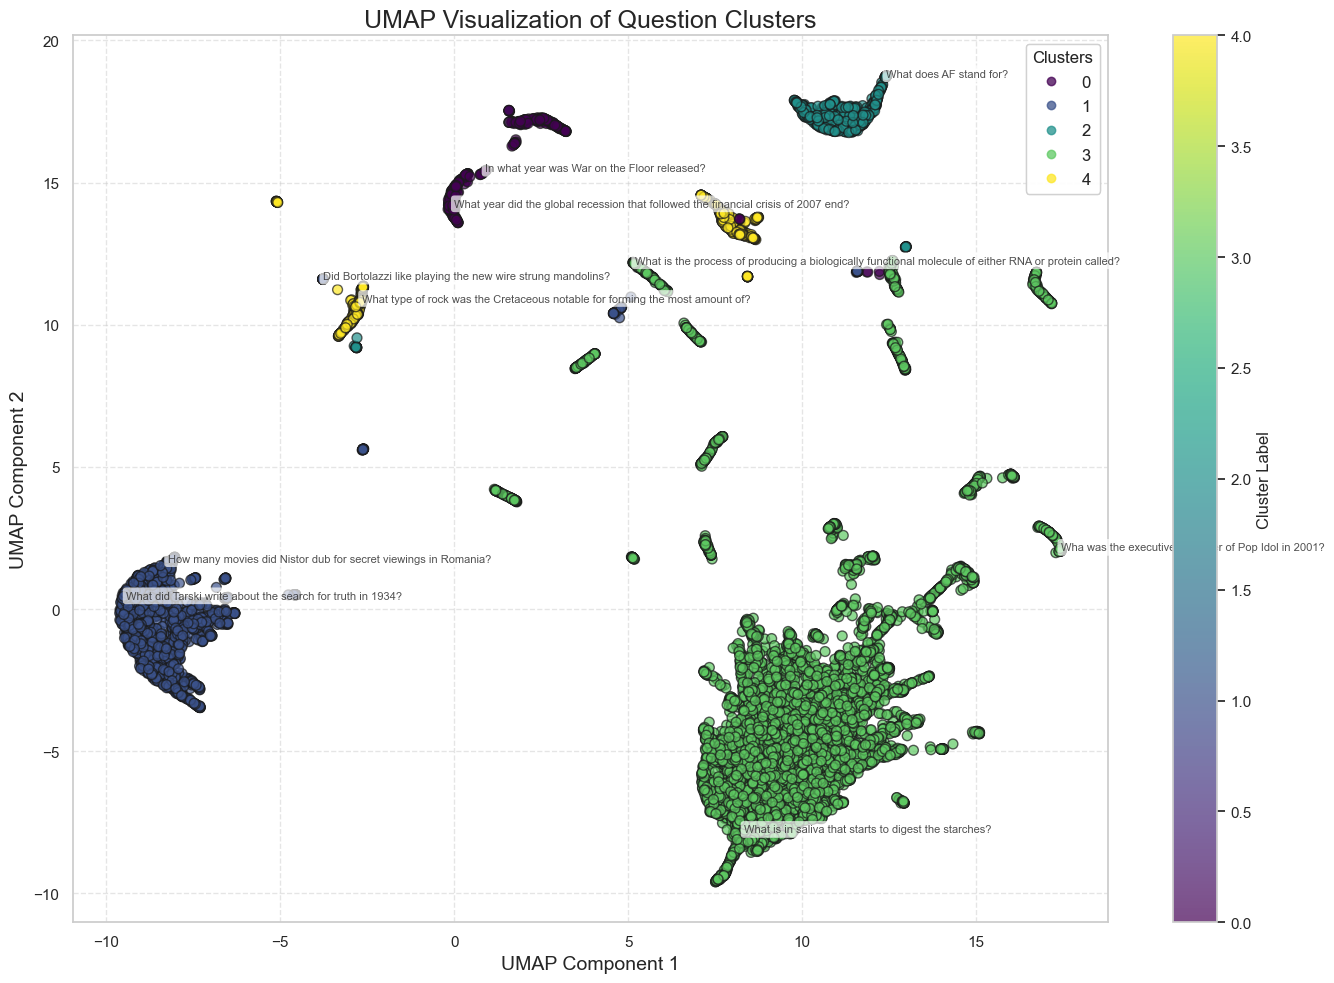

In [ ]:
plt.figure(figsize=(14, 10))

# Create a scatter plot of the UMAP results
scatter = plt.scatter(squad_sample['x'], squad_sample['y'], c=squad_sample['cluster'], cmap='viridis', alpha=0.7, edgecolor='k', s=50)

# Create a legend for clusters
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters", loc='upper right', fontsize=12)
plt.gca().add_artist(legend1)

# Annotate points with sample questions from each cluster
for i in range(len(squad_sample)):
    if i % (len(squad_sample) // 10) == 0:  # Annotate only a subset for clarity
        plt.annotate(
            squad_sample['question'].iloc[i],
            (squad_sample['x'].iloc[i], squad_sample['y'].iloc[i]),
            fontsize=8,
            alpha=0.8,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')
        )

plt.title('UMAP Visualization of Question Clusters', fontsize=18)
plt.xlabel('UMAP Component 1', fontsize=14)
plt.ylabel('UMAP Component 2', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Show color bar for cluster colors
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster Label', fontsize=12)

plt.tight_layout()
plt.show()

# Filtering Unanswerable Questions

In [ ]:
# Filter unanswerable questions from the sampled DataFrame
unanswerable_df = squad_sample[squad_sample['is_impossible'] == True]

# Verify that only unanswerable questions are included
print(f"Number of unanswerable questions in the sample: {len(unanswerable_df)}")
print(unanswerable_df[['question', 'is_impossible']].head())  # Displaying relevant columns

Number of unanswerable questions in the sample: 3266
                                                 question  is_impossible
39176   In what century did Martin Luther honor Mary a...           True
44136         How many times has the Queen toured Canada?           True
58872     What train line connects florida to the south?            True
114662   Why was every Nachlass left behind after Whit...           True
62988   What concerns are raised when thinking about a...           True


### Further Analysis of Unanswerable Questions

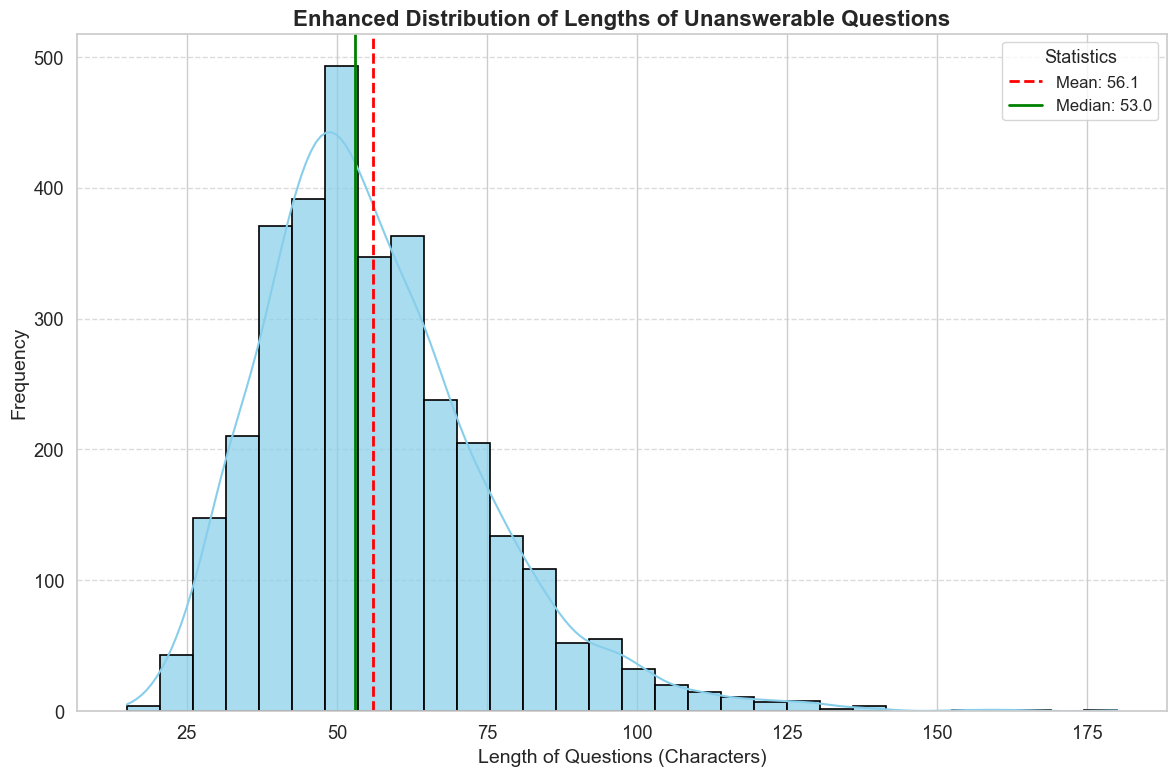

In [ ]:
sns.set(style="whitegrid", palette="muted", font_scale=1.2)

# Create the figure
plt.figure(figsize=(12, 8))

# Plot the histogram with KDE and customizations
sns.histplot(
    unanswerable_question_lengths,
    bins=30,
    kde=True,
    color="skyblue",
    alpha=0.7,
    edgecolor="black",
    linewidth=1.2,
)

# Add a vertical line for the mean length
mean_length = unanswerable_question_lengths.mean()
plt.axvline(mean_length, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_length:.1f}')

# Add a vertical line for the median length
median_length = unanswerable_question_lengths.median()
plt.axvline(median_length, color='green', linestyle='-', linewidth=2, label=f'Median: {median_length:.1f}')

# Add titles and labels
plt.title('Enhanced Distribution of Lengths of Unanswerable Questions', fontsize=16, fontweight='bold')
plt.xlabel('Length of Questions (Characters)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Add a legend
plt.legend(fontsize=12, title="Statistics", title_fontsize=13)

# Add gridlines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

### Choose a Pre-trained Model

In [ ]:
model_name = "bert-base-uncased"

In [ ]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import torch

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load the model
model = AutoModelForQuestionAnswering.from_pretrained(model_name)

# Check if GPU is available and move model to GPU if possible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

print(f"Model loaded on {device}")

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on cuda


### Testing the Model

In [ ]:
# Select a sample unanswerable question from our DataFrame
sample_question = unanswerable_df['question'].iloc[0]
sample_context = unanswerable_df['context'].iloc[0]

# Tokenize the input
inputs = tokenizer(sample_context, sample_question, return_tensors="pt", max_length=512, truncation=True)
inputs = inputs.to(device)

# Perform inference
with torch.no_grad():
    outputs = model(**inputs)

start_logits = outputs.start_logits
end_logits = outputs.end_logits

# Get predicted start and end positions
start_index = torch.argmax(start_logits)
end_index = torch.argmax(end_logits)

print("Predicted start index:", start_index.item())
print("Predicted end index:", end_index.item())

Predicted start index: 134
Predicted end index: 124


# Fine-Tuning the Model
## Preparing the Data

In [ ]:
def prepare_data(df, tokenizer, max_length=512):
    input_ids = []
    attention_masks = []
    start_positions = []
    end_positions = []

    for index, row in df.iterrows():
        context = row['context']
        question = row['question']
        answers = row['answers']
        is_impossible = row['is_impossible']

        # Tokenize the input
        encoding = tokenizer(
            context,
            question,
            return_tensors='pt',
            max_length=max_length,
            truncation=True,
            padding='max_length'
        )

        # Append input ids and attention masks
        input_ids.append(encoding['input_ids'].squeeze(0))
        attention_masks.append(encoding['attention_mask'].squeeze(0))

        # Handle unanswerable questions
        if is_impossible:
            start_positions.append(torch.tensor(0))  # Default value for unanswerable
            end_positions.append(torch.tensor(0))    # Default value for unanswerable
        else:
            if answers and len(answers) > 0:  # Ensure there's at least one answer
                answer = answers[0]['text']
                start_index = context.find(answer)

                if start_index != -1:
                    end_index = start_index + len(answer)
                    start_positions.append(torch.tensor(start_index))
                    end_positions.append(torch.tensor(end_index))
                else:
                    # If answer not found in context, default to 0
                    start_positions.append(torch.tensor(0))
                    end_positions.append(torch.tensor(0))
            else:
                # No answers provided, default to 0
                start_positions.append(torch.tensor(0))
                end_positions.append(torch.tensor(0))

    return {
        'input_ids': torch.stack(input_ids),
        'attention_masks': torch.stack(attention_masks),
        'start_positions': torch.stack(start_positions),
        'end_positions': torch.stack(end_positions)
    }

# Prepare the data using the sampled DataFrame
prepared_data = prepare_data(squad_sample, tokenizer)

## Creating DataLoaders

In [ ]:
from torch.utils.data import Dataset, DataLoader

class SquadDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data['input_ids'])

    def __getitem__(self, idx):
        return {
            'input_ids': self.data['input_ids'][idx],
            'attention_mask': self.data['attention_masks'][idx],
            'start_positions': self.data['start_positions'][idx],
            'end_positions': self.data['end_positions'][idx]
        }

# Create the Dataset
dataset = SquadDataset(prepared_data)

# Create the DataLoader
batch_size = 64  # Adjust as needed
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"  # Disable asynchronous launches (for debugging)
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Specify which GPU to use

## Fine-Tuning the Model

In [ ]:
from transformers import AdamW, get_scheduler
from tqdm import tqdm
import gc

# Enable mixed precision (fp16) for faster training
scaler = torch.cuda.amp.GradScaler()

# Set up the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Set up the learning rate scheduler
num_training_steps = len(dataloader) * 3  # Assuming 3 epochs
lr_scheduler = get_scheduler(
    "linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
)

# Move model to device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Training loop
num_epochs = 3
model.train()  # Set the model to training mode

for epoch in range(num_epochs):
    loop = tqdm(dataloader, leave=True, desc=f'Epoch {epoch + 1}/{num_epochs}')
    running_loss = 0.0

    for step, batch in enumerate(loop):
        optimizer.zero_grad()

        # Move batch tensors to the device
        input_ids = batch['input_ids'].to(device, non_blocking=True)
        attention_mask = batch['attention_mask'].to(device, non_blocking=True)
        start_positions = batch['start_positions'].to(device, non_blocking=True)
        end_positions = batch['end_positions'].to(device, non_blocking=True)

        # Enable mixed precision with autocast
        with torch.cuda.amp.autocast(dtype=torch.float16):  # Use FP16 for GPU operations
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                start_positions=start_positions,
                end_positions=end_positions
            )
            loss = outputs.loss

        # Scale the loss for mixed precision and perform backward pass
        scaler.scale(loss).backward()

        # Perform optimizer step and update scaler
        scaler.step(optimizer)
        scaler.update()

        # Update learning rate scheduler
        lr_scheduler.step()

        # Track progress
        running_loss += loss.item()
        avg_loss = running_loss / (step + 1)
        loop.set_postfix(loss=avg_loss)

        # Free memory to avoid GPU memory issues
        del loss, outputs
        torch.cuda.empty_cache()
        gc.collect()

    print(f"Epoch {epoch + 1} Loss: {avg_loss:.4f}")

C:\Users\dkmho\AppData\Local\Temp\ipykernel_13604\731303367.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1/3:   0%|          | 0/157 [00:00<?, ?it/s]


RuntimeError: CUDA error: the launch timed out and was terminated
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
import torch
from transformers import AdamW, get_scheduler, DistilBertForQuestionAnswering, DistilBertTokenizerFast
from torch.utils.data import DataLoader, TensorDataset
import os
import gc
from tqdm import tqdm
import pandas as pd
import json  # Make sure to import json
from torch.nn.utils.rnn import pad_sequence

# --- CONFIGURATION: Minimal for Testing ---
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

BATCH_SIZE = 1
NUM_EPOCHS = 1
MAX_LENGTH = 256
ACCUMULATION_STEPS = 4 # Helps simulate larger batch sizes
LEARNING_RATE = 5e-5 # Adjust learning rate if needed

# --- MODEL & TOKENIZER ---
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)
model = DistilBertForQuestionAnswering.from_pretrained(model_name)

# --- DEVICE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

try:
    model.to(device)
    print("Model moved to device successfully.")
except RuntimeError as e:
    print(f"Error moving model to device: {e}")
    exit()

# ============ DATA LOADING AND PREPARATION ============

def prepare_data(df, tokenizer, max_length): # Use all dataset to test the functions
    input_ids = []
    attention_masks = []
    start_positions = []
    end_positions = []

    for index, row in df.iterrows(): #iterate throgh all function
        context = row['context']
        question = row['question']
        answers = row['answers']
        is_impossible = row['is_impossible']

        encoding = tokenizer(
            question,
            context,
            return_tensors='pt',
            max_length=max_length,
            truncation=True,
            padding='max_length'
        )

        input_ids.append(encoding['input_ids'].squeeze(0))
        attention_masks.append(encoding['attention_mask'].squeeze(0))

        if is_impossible:
            start_positions.append(torch.tensor(0))
            end_positions.append(torch.tensor(0))
        else:
            # Added check for answers in the form that follows squadData format
            if isinstance(answers, list) and len(answers) > 0:  # Make sure it's a list and not empty
                if 'text' in answers[0]:  # Make sure 'text' key exists
                    answer_text = answers[0]['text']
                    start_index = context.find(answer_text)
                    end_index = start_index + len(answer_text) if start_index != -1 else 0
                    start_positions.append(torch.tensor(start_index))
                    end_positions.append(torch.tensor(end_index))
                else:
                    start_positions.append(torch.tensor(0))
                    end_positions.append(torch.tensor(0))
            else:
                start_positions.append(torch.tensor(0))
                end_positions.append(torch.tensor(0))

    return input_ids, attention_masks, start_positions, end_positions

#Load data
file_path = "C:\SQUAD\squad_train-v2.0.json"
with open(file_path, 'r', encoding='utf-8') as f:
    squad_json = json.load(f)

#Data Processing
squad_data = []
for data in squad_json['data']:
    for paragraph in data['paragraphs']:
        for qas in paragraph['qas']:
            question = qas['question']
            id = qas['id']
            is_impossible = qas['is_impossible']
            answers = qas['answers'] if 'answers' in qas else []
            context = paragraph['context']
            squad_data.append([id, data['title'], context, question, is_impossible, answers])

squad_df = pd.DataFrame(squad_data, columns=['id', 'title', 'context', 'question', 'is_impossible', 'answers'])

squad_df.dropna(subset=['context', 'question', 'answers'], inplace=True)
squad_df.reset_index(drop=True, inplace=True)

squad_sample = squad_df.head(8) # Take the 8 row

# ============ DATA LOADING AND PREPARATION ============
# Pad input_ids and attention_masks
try:
    input_ids, attention_masks, start_positions, end_positions = prepare_data(squad_sample, tokenizer, max_length=MAX_LENGTH)

    # Pad sequences to a uniform length

    input_ids_padded = pad_sequence(input_ids, batch_first=True, padding_value=tokenizer.pad_token_id)
    attention_masks_padded = pad_sequence(attention_masks, batch_first=True, padding_value=0)
    start_positions_padded = torch.stack(start_positions)
    end_positions_padded = torch.stack(end_positions)

except Exception as e:
    print(f"Error during data preparation: {e}")
    exit()

# ============ TENSOR DATASET SECTION ============

dataset = TensorDataset(
    input_ids_padded,
    attention_masks_padded,
    start_positions_padded,
    end_positions_padded
)

dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- OPTIMIZER AND SCHEDULER ---
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
num_training_steps = len(dataloader) * NUM_EPOCHS // ACCUMULATION_STEPS
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

# --- MIXED PRECISION ---
scaler = torch.cuda.amp.GradScaler()

# --- TRAINING LOOP ---
print("Starting Training Loop...")
model.train()

for epoch in range(NUM_EPOCHS):
    loop = tqdm(dataloader, leave=True, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    running_loss = 0.0
    optimizer.zero_grad()

    for step, batch in enumerate(loop):
        input_ids = batch[0].to(device, non_blocking=True)
        attention_mask = batch[1].to(device, non_blocking=True)
        start_positions = batch[2].to(device, non_blocking=True)
        end_positions = batch[3].to(device, non_blocking=True)

        with torch.cuda.amp.autocast(dtype=torch.float16):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                start_positions=start_positions,
                end_positions=end_positions,
            )
            loss = outputs.loss / ACCUMULATION_STEPS

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        if (step + 1) % ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            lr_scheduler.step()
            optimizer.zero_grad()

        running_loss += loss.item() * ACCUMULATION_STEPS
        avg_loss = running_loss / (step + 1)
        loop.set_postfix(loss=avg_loss)

        del loss, outputs, input_ids, attention_mask, start_positions, end_positions
        torch.cuda.empty_cache()
        gc.collect()

    print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

<>:85: SyntaxWarning: invalid escape sequence '\S'
<>:85: SyntaxWarning: invalid escape sequence '\S'
C:\Users\dkmho\AppData\Local\Temp\ipykernel_18212\2480012818.py:85: SyntaxWarning: invalid escape sequence '\S'
  file_path = "C:\SQUAD\squad_train-v2.0.json"
Some weights of DistilBertForQuestionAnswering were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Device: cuda
Model moved to device successfully.


C:\Users\dkmho\AppData\Roaming\Python\Python312\site-packages\transformers\optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
C:\Users\dkmho\AppData\Local\Temp\ipykernel_18212\2480012818.py:146: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Starting Training Loop...


Epoch 1/1:   0%|          | 0/8 [00:00<?, ?it/s]C:\Users\dkmho\AppData\Local\Temp\ipykernel_18212\2480012818.py:163: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float16):
Epoch 1/1: 100%|██████████| 8/8 [00:10<00:00,  1.36s/it, loss=nan]

Epoch 1 Loss: nan
